# Integration method comparisons for Berton (2023) Case 0

This notebook compares the saved explicit-Euler reproduction outputs from `replicate-steady-state.ipynb` and `replicate-oscillatory-state.ipynb` against SciPy `solve_ivp` integrations using `Radau`, `BDF`, and `LSODA`.

Two modes are shown:

1. **Fixed output time**: `output_dt` is matched to the saved Euler CSV cadence so trajectories can be compared at the same sample times.
2. **Native/adaptive output**: `output_dt=None`, allowing each SciPy method to choose its own output times.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo = Path.cwd().resolve()
if repo.name == "notebooks":
    repo = repo.parent
src = repo / "src"
if src.exists() and str(src) not in sys.path:
    sys.path.insert(0, str(src))

from cloud_rom import berton2023 as b
from cloud_rom import berton2023_plots as bp

notebook_dir = repo / "notebooks"
plt.rcParams["figure.figsize"] = (10, 4)


## Load saved explicit-Euler baselines

These CSV files are numeric magnitude outputs generated by the two reproduction notebooks. They are used as the baseline rather than rerunning Euler here.


In [2]:
baselines = {
    "steady": pd.read_csv(notebook_dir / "df_steady_magnitudes.csv"),
    "oscillatory": pd.read_csv(notebook_dir / "df_oscillatory_magnitudes.csv"),
}

for name, df in baselines.items():
    dt_h = float(np.median(np.diff(df["t_h"])))
    print(f"{name:11s}: {len(df):5d} rows, duration={df['t_h'].iloc[-1]:.3f} h, output_dt={dt_h * 3600:.3f} s")


steady     :  1801 rows, duration=5.000 h, output_dt=10.000 s
oscillatory:  2401 rows, duration=40.000 h, output_dt=60.000 s


## Run SciPy integrations

`simulate_with_method(...)` is a convenience wrapper around `simulate(...)`; it replaces the integration method without requiring a new `SimulationConfig` for each method.

The fixed-output runs use the same output cadence as the saved Euler CSVs. The native-output runs leave `output_dt=None`, so the solver controls returned time points.

Each integration is run with `progress=True`, so the solver progress bar reports elapsed model seconds for the current method/scenario.


In [3]:
METHODS = ["Radau", "BDF", "LSODA"]
SCIPY_OPTIONS = {"rtol": 1e-6, "atol": 1e-9}

def scenario_config(name: str, baseline: pd.DataFrame):
    oscillatory = name == "oscillatory"
    duration_h = float(baseline["t_h"].iloc[-1])
    output_dt_h = float(np.median(np.diff(baseline["t_h"])))
    return {
        "oscillatory": oscillatory,
        "duration_h": duration_h,
        "output_dt_h": output_dt_h,
        "atmosphere": b.atmosphere_for_case(0, oscillatory=oscillatory),
        "initial_state": b.initial_state_for_case(0),
        "config": b.SimulationConfig(
            duration=b.Q_(duration_h, "hour"),
            dt=b.Q_(0.04, "s"),  # only used if method="euler"
            include_coriolis=False,
            stop_on_nonpositive_mass=True,
        ),
    }

def run_method(name: str, method: str, *, fixed_output: bool) -> pd.DataFrame:
    sc = scenario_config(name, baselines[name])
    output_dt = b.Q_(sc["output_dt_h"], "hour") if fixed_output else None
    df = b.simulate_with_method(
        method,
        sc["initial_state"],
        sc["atmosphere"],
        config=sc["config"],
        output_dt=output_dt,
        scipy_options=SCIPY_OPTIONS,
        progress=True,
        progress_desc=f"{name} {method} ({'fixed output' if fixed_output else 'native output'})",
    )
    return bp.magnitude_frame(df, sc["atmosphere"])

fixed_runs = {
    scenario: {method: run_method(scenario, method, fixed_output=True) for method in METHODS}
    for scenario in baselines
}
native_runs = {
    scenario: {method: run_method(scenario, method, fixed_output=False) for method in METHODS}
    for scenario in baselines
}


steady Radau (fixed output):   0%|          | 0/18000.000000300057 [00:00<?, ?s/s]

steady BDF (fixed output):   0%|          | 0/18000.000000300057 [00:00<?, ?s/s]

steady LSODA (fixed output):   0%|          | 0/18000.000000300057 [00:00<?, ?s/s]

oscillatory Radau (fixed output):   0%|          | 0/143999.99999338816 [00:00<?, ?s/s]

oscillatory BDF (fixed output):   0%|          | 0/143999.99999338816 [00:00<?, ?s/s]

...

steady BDF (native output):   0%|          | 0/18000.000000300057 [00:00<?, ?s/s]

steady LSODA (native output):   0%|          | 0/18000.000000300057 [00:00<?, ?s/s]

oscillatory Radau (native output):   0%|          | 0/143999.99999338816 [00:00<?, ?s/s]

oscillatory BDF (native output):   0%|          | 0/143999.99999338816 [00:00<?, ?s/s]

oscillatory LSODA (native output):   0%|          | 0/143999.99999338816 [00:00<?, ?s/s]

## Fixed-output comparison with explicit Euler

Each SciPy run is sampled at the same output times as the saved Euler baseline. The first row overlays the trajectories; the second row shows method-minus-Euler differences in altitude and mass.


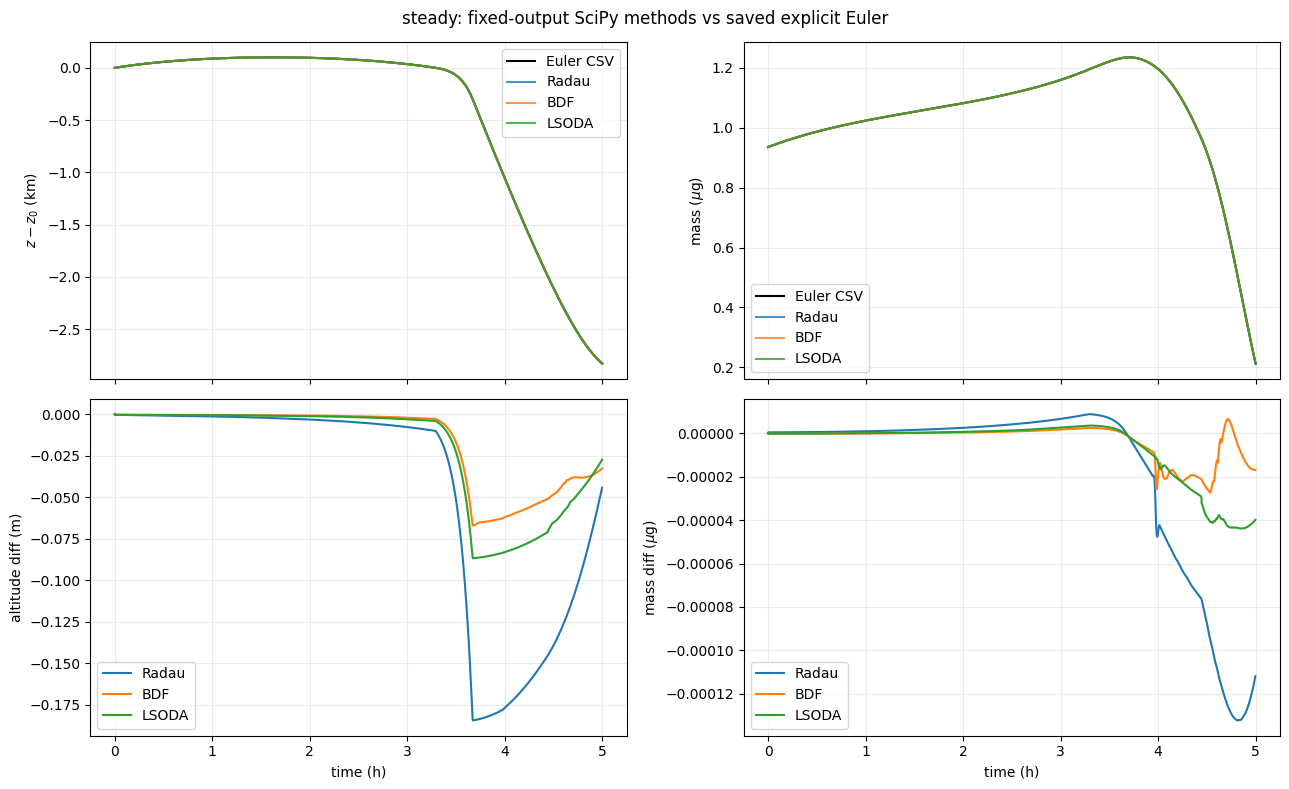

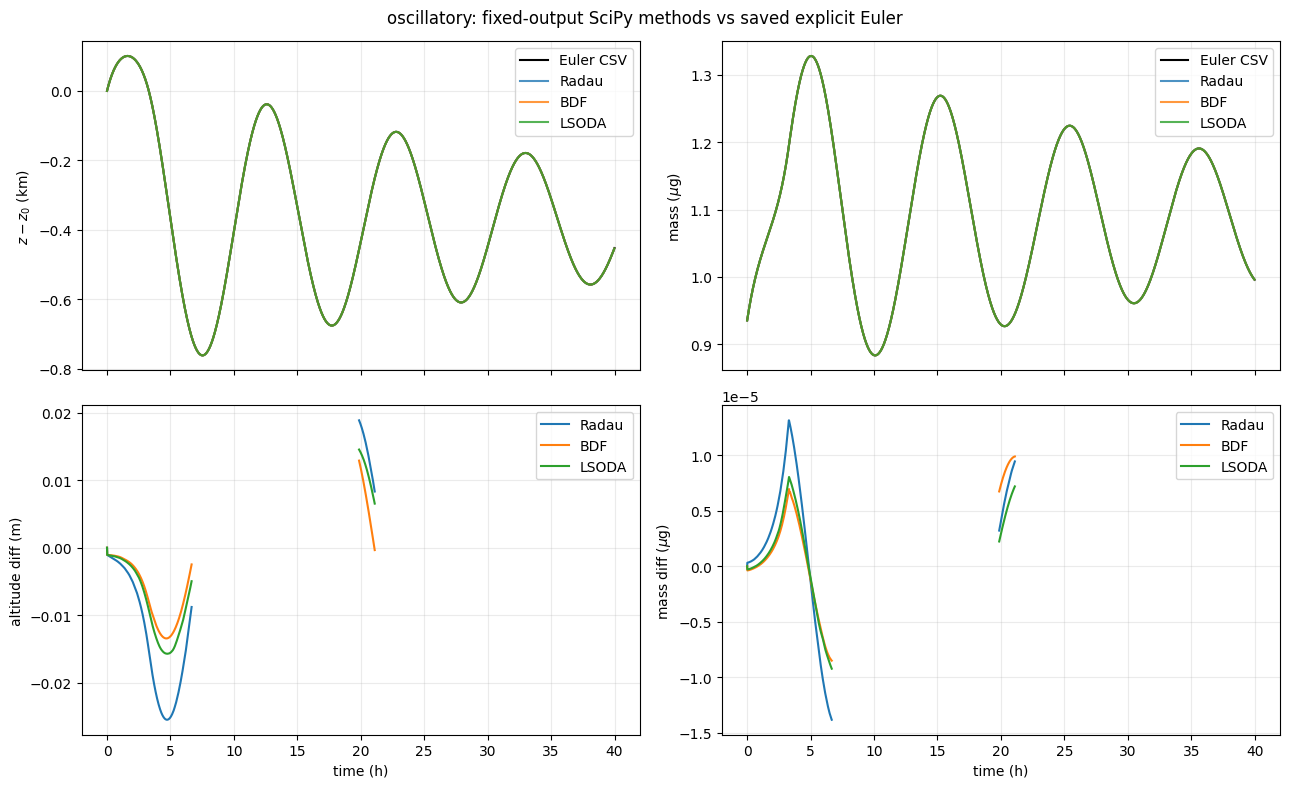

In [4]:
def plot_fixed_comparison(scenario: str):
    euler = baselines[scenario]
    fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex="col")
    fig.suptitle(f"{scenario}: fixed-output SciPy methods vs saved explicit Euler")

    axes[0, 0].plot(euler["t_h"], euler["z_minus_z0_km"], "k-", label="Euler CSV")
    axes[0, 1].plot(euler["t_h"], euler["m_ug"], "k-", label="Euler CSV")

    for method, df in fixed_runs[scenario].items():
        axes[0, 0].plot(df["t_h"], df["z_minus_z0_km"], label=method, alpha=0.8)
        axes[0, 1].plot(df["t_h"], df["m_ug"], label=method, alpha=0.8)

        merged = pd.merge_asof(
            df.sort_values("t_h"),
            euler.sort_values("t_h"),
            on="t_h",
            suffixes=("", "_euler"),
            tolerance=1e-10,
            direction="nearest",
        )
        axes[1, 0].plot(merged["t_h"], 1000 * (merged["z_minus_z0_km"] - merged["z_minus_z0_km_euler"]), label=method)
        axes[1, 1].plot(merged["t_h"], merged["m_ug"] - merged["m_ug_euler"], label=method)

    axes[0, 0].set_ylabel(r"$z-z_0$ (km)")
    axes[0, 1].set_ylabel(r"mass ($\mu$g)")
    axes[1, 0].set_ylabel("altitude diff (m)")
    axes[1, 1].set_ylabel(r"mass diff ($\mu$g)")
    axes[1, 0].set_xlabel("time (h)")
    axes[1, 1].set_xlabel("time (h)")
    for ax in axes.flat:
        ax.grid(True, alpha=0.25)
        ax.legend()
    fig.tight_layout()
    return fig

plot_fixed_comparison("steady");
plot_fixed_comparison("oscillatory");


## Native/adaptive output times

With `output_dt=None`, `solve_ivp` returns the solver's own accepted output times. This is the mode expected for future work once Euler and fixed-output comparison are no longer needed.


In [5]:
for scenario, runs in native_runs.items():
    print(f"\n{scenario}")
    for method, df in runs.items():
        dt_s = np.diff(df["t_h"]) * 3600
        print(
            f"  {method:5s}: rows={len(df):5d}, "
            f"dt range=({dt_s.min():.3g}, {dt_s.max():.3g}) s, "
            f"median={np.median(dt_s):.3g} s"
        )



steady
  Radau: rows=  188, dt range=(0.00153, 452) s, median=18.8 s
  BDF  : rows=  341, dt range=(9.41e-06, 456) s, median=0.564 s
  LSODA: rows=  395, dt range=(6.13e-05, 407) s, median=7.93 s

oscillatory
  Radau: rows=  345, dt range=(0.00153, 839) s, median=451 s
  BDF  : rows=  432, dt range=(9.41e-06, 793) s, median=343 s
  LSODA: rows=  665, dt range=(6.13e-05, 756) s, median=207 s


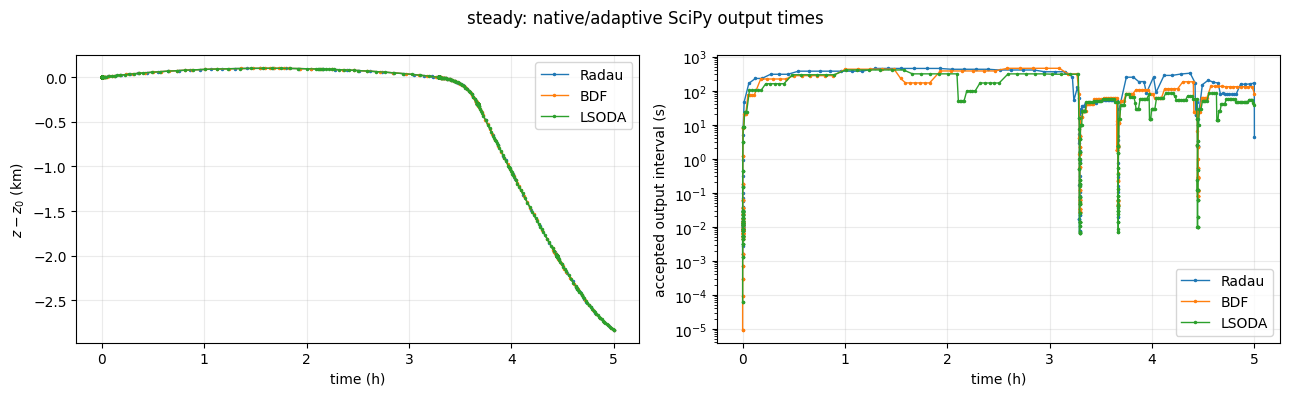

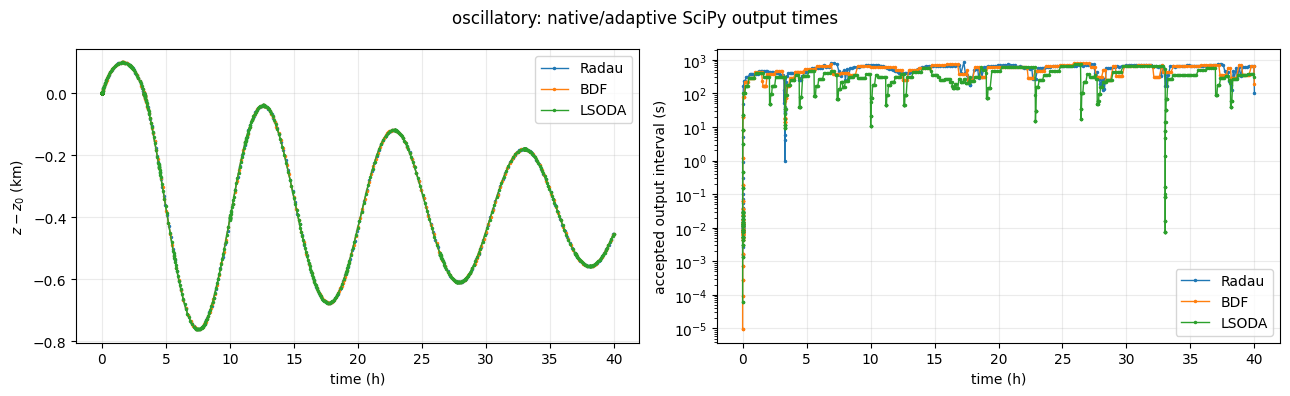

In [6]:
def plot_native_outputs(scenario: str):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f"{scenario}: native/adaptive SciPy output times")
    for method, df in native_runs[scenario].items():
        axes[0].plot(df["t_h"], df["z_minus_z0_km"], marker=".", ms=3, lw=1, label=method)
        dt_s = np.diff(df["t_h"]) * 3600
        axes[1].semilogy(df["t_h"].iloc[1:], dt_s, marker=".", ms=3, lw=1, label=method)
    axes[0].set_xlabel("time (h)")
    axes[0].set_ylabel(r"$z-z_0$ (km)")
    axes[1].set_xlabel("time (h)")
    axes[1].set_ylabel("accepted output interval (s)")
    for ax in axes:
        ax.grid(True, alpha=0.25)
        ax.legend()
    fig.tight_layout()
    return fig

plot_native_outputs("steady");
plot_native_outputs("oscillatory");
